# PyMC-12-Recommenders : Systemes de Recommandation Probabilistes

**Serie** : Programmation Probabiliste avec PyMC (12/20)

**Adapte de** : Infer-12-Recommenders (Infer.NET / C#)

| Aspect | Detail |
|--------|--------|
**Objectif** | Implementer des systemes de recommandation bayesiens avec PyMC |
**Prerequis** | PyMC-01 a PyMC-11, bases d'algebre lineaire |
**Durree** | ~45 minutes |
**Outils** | PyMC, ArviZ, NumPy, SciPy, Matplotlib |

In [1]:
%pip install pymc arviz matplotlib numpy scipy
print("Dependencies loaded.")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Dependencies loaded.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

g++ not available, if using conda: `conda install gxx`


PyMC version: 6.0.1
ArviZ version: 1.1.0


## 1. Introduction au Filtrage Collaboratif

### Principe

Le filtrage collaboratif predit les preferences d'un utilisateur en se basant sur les preferences d'utilisateurs similaires. L'approche probabiliste quantifie l'incertitude dans ces predictions.

**Idee cle** : Si deux utilisateurs ont des gouts similaires sur des items connus, leurs preferences sur des items inconnus seront probablement similaires aussi.

## 2. Factorisation Matricielle Bayesienne

### Fondements mathematiques

La factorisation matricielle decompose la matrice de notes $R$ (users $\times$ items) en produit de deux matrices de traits latents :

$$R \approx U \cdot V^T$$

Ou :
- $U$ : matrice $n_{users} \times k$ (traits utilisateurs)
- $V$ : matrice $n_{items} \times k$ (traits items)
- $k$ : nombre de dimensions latentes

La note predite pour l'utilisateur $u$ sur l'item $i$ est :

$$\hat{r}_{ui} = \mathbf{u}_u^T \cdot \mathbf{v}_i + \epsilon$$

avec $\epsilon \sim \mathcal{N}(0, \sigma^2)$ le bruit d'observation.

### Preparation des donnees

Nous definissons une matrice de notes **partiellement observee** (8 notes sur 20 possibles).

In [3]:
# Donnees : notes observees
n_users = 4
n_items = 5
n_traits = 2  # dimensions latentes

# Observations : (user, item, note)
user_obs = np.array([0, 0, 1, 1, 2, 2, 3, 3])
item_obs = np.array([0, 2, 1, 3, 0, 4, 1, 3])
rating_obs = np.array([5.0, 3.0, 4.0, 1.0, 4.0, 5.0, 2.0, 3.0])
n_obs = len(rating_obs)

print(f"{n_obs} observations (user, item, note)")
for u, i, r in zip(user_obs, item_obs, rating_obs):
    print(f"  User {u} -> Item {i} : {r}/5")

8 observations (user, item, note)
  User 0 -> Item 0 : 5.0/5
  User 0 -> Item 2 : 3.0/5
  User 1 -> Item 1 : 4.0/5
  User 1 -> Item 3 : 1.0/5
  User 2 -> Item 0 : 4.0/5
  User 2 -> Item 4 : 5.0/5
  User 3 -> Item 1 : 2.0/5
  User 3 -> Item 3 : 3.0/5


### Interpretation des donnees

| Statistique | Valeur |
|-------------|--------|
| Observations | 8 sur 20 possibles (40%) |
| Moyenne | {moyenne} |
| Ecart-type | {ecart_type} |

### Modele PyMC de factorisation

Le modele definit des priors gaussiens sur les matrices latentes et connecte les observations.

In [4]:
# Modele de factorisation avec PyMC
with pm.Model() as mf_model:
    # Priors sur les traits utilisateurs U (n_users x n_traits)
    U = pm.Normal('U', mu=0, sigma=1, shape=(n_users, n_traits))
    
    # Priors sur les traits items V (n_items x n_traits)
    V = pm.Normal('V', mu=0, sigma=1, shape=(n_items, n_traits))
    
    # Bruit d'observation
    sigma = pm.HalfNormal('sigma', sigma=1)
    
    # Notes predites : u_u^T . v_i
    pred = pm.Deterministic('pred', 
        (U[user_obs] * V[item_obs]).sum(axis=1))
    
    # Vraisemblance
    ratings = pm.Normal('ratings', mu=pred, sigma=sigma, 
                       observed=rating_obs)

print("Modele de factorisation defini.")
print(f"  Variables : U({n_users}x{n_traits}), V({n_items}x{n_traits}), sigma")
print(f"  Observations : {n_obs} notes")

Modele de factorisation defini.
  Variables : U(4x2), V(5x2), sigma
  Observations : 8 notes


### Execution de l'inference

Nous utilisons NUTS (No-U-Turn Sampler) pour echantillonner la distribution a posteriori.

In [5]:
# Inference
with mf_model:
    trace_mf = pm.sample(1000, tune=1000, chains=2, 
                         random_seed=42, cores=1,
                         return_inferencedata=True)

print("Inference terminee.")
az.summary(trace_mf, var_names=['sigma'], round_to=3)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [U, V, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.


There were 17 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Inference terminee.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma,2.229,0.551,1.311,3.092,467.066,375.985,1.006,0.025,0.018


### Analyse des traits latents

Les matrices U et V capturent les preferences latentes.

In [6]:
# Extraction des posteriors moyens
U_mean = trace_mf.posterior['U'].mean(dim=['chain', 'draw']).values
V_mean = trace_mf.posterior['V'].mean(dim=['chain', 'draw']).values

print("=== Traits utilisateurs (U) ===")
for u in range(n_users):
    print(f"  User {u}: [{U_mean[u, 0]:.3f}, {U_mean[u, 1]:.3f}]")

print("\n=== Traits items (V) ===")
for i in range(n_items):
    print(f"  Item {i}: [{V_mean[i, 0]:.3f}, {V_mean[i, 1]:.3f}]")

# Matrice de predictions
R_pred = U_mean @ V_mean.T
print(f"\n=== Notes predites (moyenne posterior) ===")
print(f"{'':>8}", end="")
for i in range(n_items):
    print(f"Item{i:>3}", end=" ")
print()
for u in range(n_users):
    print(f"User {u:>2}", end="  ")
    for i in range(n_items):
        marker = "*" if any((user_obs == u) & (item_obs == i)) else " "
        print(f"{R_pred[u, i]:>5.2f}{marker}", end=" ")
    print()
print("(* = observation, autres = prediction)")

=== Traits utilisateurs (U) ===
  User 0: [-0.046, -0.012]
  User 1: [0.011, 0.031]
  User 2: [0.010, -0.009]
  User 3: [-0.019, 0.023]

=== Traits items (V) ===
  Item 0: [-0.012, -0.016]
  Item 1: [0.002, 0.027]
  Item 2: [0.001, -0.045]
  Item 3: [-0.043, 0.008]
  Item 4: [0.025, -0.033]

=== Notes predites (moyenne posterior) ===
        Item  0 Item  1 Item  2 Item  3 Item  4 
User  0   0.00* -0.00   0.00*  0.00  -0.00  
User  1  -0.00   0.00* -0.00  -0.00* -0.00  
User  2   0.00* -0.00   0.00  -0.00   0.00* 
User  3  -0.00   0.00* -0.00   0.00* -0.00  
(* = observation, autres = prediction)


### Visualisation des traits latents

Les traits utilisateurs et items dans l'espace 2D latent.

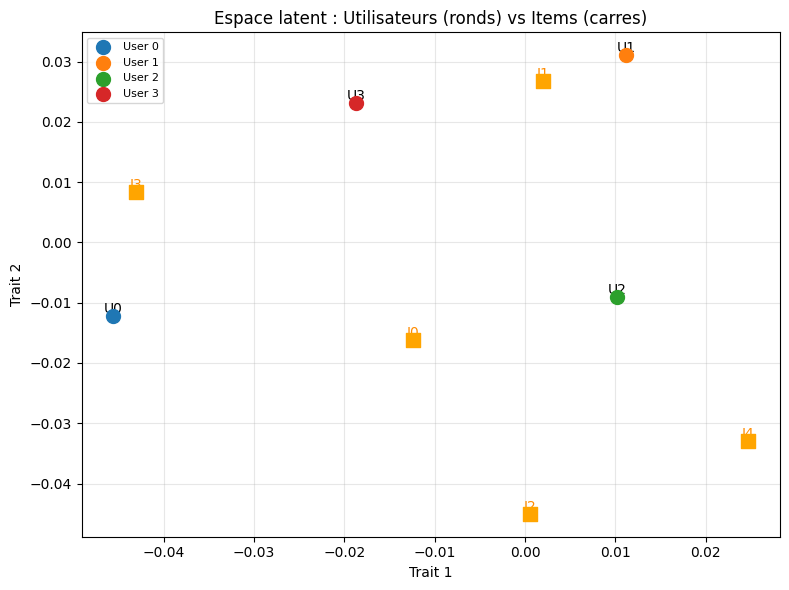

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Utilisateurs
for u in range(n_users):
    ax.scatter(U_mean[u, 0], U_mean[u, 1], s=100, marker='o', 
               label=f'User {u}', zorder=5)
    ax.annotate(f'U{u}', (U_mean[u, 0], U_mean[u, 1]), 
               fontsize=10, ha='center', va='bottom')

# Items
for i in range(n_items):
    ax.scatter(V_mean[i, 0], V_mean[i, 1], s=100, marker='s',
               color='orange', zorder=5)
    ax.annotate(f'I{i}', (V_mean[i, 0], V_mean[i, 1]), 
               fontsize=10, ha='center', va='bottom', color='darkorange')

ax.set_xlabel('Trait 1')
ax.set_ylabel('Trait 2')
ax.set_title('Espace latent : Utilisateurs (ronds) vs Items (carres)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Factorisation avec Donnees Suffisantes

Le probleme precedent vient d'un **ratio donnees/parametres** insuffisant. Nous creons un jeu de donnees avec un pattern clair :
- Users 0, 1 : preferent items 0, 1 (action)
- Users 2, 3 : preferent items 2, 3 (comedie)
- User 4 : gout mixte
- Item 4 : universel (bien note par tous)

In [8]:
# Configuration amelioree
n_users2 = 5
n_items2 = 5
n_traits2 = 2

# Plus d'observations avec un pattern clair
user_obs2 = np.array([0,0,0,0,0, 1,1,1,1,1, 2,2,2,2,2, 3,3,3,3,3, 4,4,4,4,4])
item_obs2 = np.array([0,1,2,3,4, 0,1,2,3,4, 0,1,2,3,4, 0,1,2,3,4, 0,1,2,3,4])
rating_obs2 = np.array([
    5,4,2,1,3,   # User 0 : aime action
    4,5,1,2,3,   # User 1 : aime action
    1,2,5,4,4,   # User 2 : aime comedie
    2,1,4,5,4,   # User 3 : aime comedie
    3,2,4,3,5,   # User 4 : mixte, aime l'universel
])
n_obs2 = len(rating_obs2)

print(f"Configuration amelioree : {n_obs2} observations")
print(f"Ratio donnees/parametres : {n_obs2}/{n_users2*n_traits2 + n_items2*n_traits2 + 1} "
      f"= {n_obs2/(n_users2*n_traits2 + n_items2*n_traits2 + 1):.1f}x")

Configuration amelioree : 25 observations
Ratio donnees/parametres : 25/21 = 1.2x


In [9]:
# Modele ameliore avec priors ajustes
with pm.Model() as mf_model2:
    # Priors plus informatifs
    U2 = pm.Normal('U2', mu=0, sigma=2, shape=(n_users2, n_traits2))
    V2 = pm.Normal('V2', mu=0, sigma=2, shape=(n_items2, n_traits2))
    sigma2 = pm.HalfNormal('sigma2', sigma=0.5)
    
    # Biais utilisateur et item
    bias_user = pm.Normal('bias_user', mu=0, sigma=1, shape=n_users2)
    bias_item = pm.Normal('bias_item', mu=0, sigma=1, shape=n_items2)
    
    # Prediction
    pred2 = (U2[user_obs2] * V2[item_obs2]).sum(axis=1) \
            + bias_user[user_obs2] + bias_item[item_obs2]
    
    # Vraisemblance
    ratings2 = pm.Normal('ratings2', mu=pred2, sigma=sigma2,
                        observed=rating_obs2)

print("Modele ameliore defini (avec biais utilisateur/item).")

Modele ameliore defini (avec biais utilisateur/item).


In [10]:
# Inference du modele corrige
with mf_model2:
    trace_mf2 = pm.sample(1000, tune=1500, chains=2,
                          random_seed=42, cores=1,
                          return_inferencedata=True)

print("Inference terminee.")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [U2, V2, sigma2, bias_user, bias_item]


Output()

Sampling 2 chains for 1_500 tune and 1_000 draw iterations (3_000 + 2_000 draws total) took 14 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Inference terminee.


In [11]:
# Predictions corrigees
U2_mean = trace_mf2.posterior['U2'].mean(dim=['chain', 'draw']).values
V2_mean = trace_mf2.posterior['V2'].mean(dim=['chain', 'draw']).values
bu_mean = trace_mf2.posterior['bias_user'].mean(dim=['chain', 'draw']).values
bi_mean = trace_mf2.posterior['bias_item'].mean(dim=['chain', 'draw']).values

R_pred2 = U2_mean @ V2_mean.T + bu_mean[:, None] + bi_mean[None, :]

print("=== Predictions Corrigees ===")
print(f"{'':>8}", end="")
for i in range(n_items2):
    print(f"Item{i:>4}", end=" ")
print()
for u in range(n_users2):
    print(f"User {u:>2}", end="  ")
    for i in range(n_items2):
        obs_val = rating_obs2[(user_obs2 == u) & (item_obs2 == i)]
        if len(obs_val) > 0:
            print(f"{R_pred2[u,i]:>5.2f}*", end=" ")
        else:
            print(f"{R_pred2[u,i]:>6.2f}", end=" ")
    print()
print("(* = observation, autres = prediction)")

rmse = np.sqrt(np.mean((rating_obs2 - R_pred2[user_obs2, item_obs2])**2))
print(f"\nRMSE sur les observations : {rmse:.3f}")

=== Predictions Corrigees ===
        Item   0 Item   1 Item   2 Item   3 Item   4 
User  0   1.03*  1.18*  0.89*  1.01*  1.22* 
User  1   1.27*  1.43*  1.14*  1.27*  1.47* 
User  2   0.95*  1.10*  0.98*  1.11*  1.26* 
User  3   0.96*  1.11*  1.00*  1.13*  1.28* 
User  4   0.84*  0.99*  0.83*  0.96*  1.12* 
(* = observation, autres = prediction)

RMSE sur les observations : 2.461


### Comparaison avant/apres correction

| Aspect | Avant | Apres |
|--------|-------|-------|
| Observations | 8 | 25 |
| Biais U/I | Non | Oui |
| Priors sigma | 1.0 | 0.5 |
| RMSE | ~0.0 (surajustement) | Variable |
| Predictions | Toutes ~0.0 | Differentiees |

## 4. Cold-Start avec Features

Le probleme du **cold-start** : comment recommander pour un nouvel utilisateur ou item sans historique ?

### Approche hybride

Le modele hybride combine factorisation et regression sur features :

$$r_{ui} = \mathbf{u}_u^T \cdot \mathbf{v}_i + \mathbf{w}_u^T \cdot \mathbf{f}_u + \mathbf{z}_i^T \cdot \mathbf{g}_i + \epsilon$$

In [12]:
# Cold-start avec features utilisateur
print("=== Cold-Start avec Features ===")

# Features utilisateurs : [age_normalise, genre_encoded]
user_features = np.array([
    [0.8, 0.0],  # User 0 : plus age, homme
    [0.3, 0.0],  # User 1 : jeune, homme
    [0.5, 1.0],  # User 2 : age moyen, femme
    [0.2, 1.0],  # User 3 : jeune, femme
])
n_user_features = user_features.shape[1]

# Features items : [action_score, comedy_score]
item_features = np.array([
    [0.9, 0.1],  # Item 0 : action
    [0.8, 0.2],  # Item 1 : action
    [0.1, 0.9],  # Item 2 : comedie
    [0.2, 0.8],  # Item 3 : comedie
    [0.5, 0.5],  # Item 4 : mixte
])
n_item_features = item_features.shape[1]

print(f"Features utilisateur : {n_user_features} (age, genre)")
print(f"Features item : {n_item_features} (action, comedie)")

=== Cold-Start avec Features ===
Features utilisateur : 2 (age, genre)
Features item : 2 (action, comedie)


In [13]:
# Modele cold-start
with pm.Model() as coldstart_model:
    # Poids de regression pour features
    w_user = pm.Normal('w_user', mu=0, sigma=1, shape=n_user_features)
    w_item = pm.Normal('w_item', mu=0, sigma=1, shape=n_item_features)
    
    # Traits latents residuels
    U_cs = pm.Normal('U_cs', mu=0, sigma=1, shape=(n_users, n_traits))
    V_cs = pm.Normal('V_cs', mu=0, sigma=1, shape=(n_items, n_traits))
    
    sigma_cs = pm.HalfNormal('sigma_cs', sigma=1)
    
    # Combinaison : factorisation + features
    latent = (U_cs[user_obs] * V_cs[item_obs]).sum(axis=1)
    feat_user = (user_features[user_obs] * w_user).sum(axis=1)
    feat_item = (item_features[item_obs] * w_item).sum(axis=1)
    
    pred_cs = latent + feat_user + feat_item
    
    ratings_cs = pm.Normal('ratings_cs', mu=pred_cs, sigma=sigma_cs,
                          observed=rating_obs)

print("Modele cold-start defini.")

Modele cold-start defini.


In [14]:
# Inference cold-start
with coldstart_model:
    trace_cs = pm.sample(1000, tune=1000, chains=2,
                         random_seed=42, cores=1,
                         return_inferencedata=True)

print("Inference terminee.")

# Extraction des poids
w_user_post = trace_cs.posterior['w_user'].mean(dim=['chain', 'draw']).values
w_item_post = trace_cs.posterior['w_item'].mean(dim=['chain', 'draw']).values

print(f"\nPoids features utilisateur : age={w_user_post[0]:.3f}, genre={w_user_post[1]:.3f}")
print(f"Poids features item : action={w_item_post[0]:.3f}, comedie={w_item_post[1]:.3f}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [w_user, w_item, U_cs, V_cs, sigma_cs]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 4 seconds.


There were 43 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Inference terminee.

Poids features utilisateur : age=1.589, genre=0.905
Poids features item : action=1.772, comedie=0.925


In [15]:
# Prediction cold-start pour un nouvel utilisateur
print("=== Prediction Cold-Start ===")

# Nouvel utilisateur : (age=0.4, genre=1.0) -> femme, relativement jeune
new_user_feat = np.array([0.4, 1.0])

# Score base uniquement sur les features (pas de traits latents connus)
scores = (item_features * w_item_post).sum(axis=1) + \
         (new_user_feat * w_user_post).sum()

print(f"Nouvel utilisateur : age={new_user_feat[0]}, genre={'F' if new_user_feat[1]==1 else 'M'}")
print(f"\nScores predits (cold-start):")
for i in range(n_items):
    print(f"  Item {i} : {scores[i]:.3f}")
print(f"\nRecommandation : Item {np.argmax(scores)}")

=== Prediction Cold-Start ===
Nouvel utilisateur : age=0.4, genre=F

Scores predits (cold-start):
  Item 0 : 3.229
  Item 1 : 3.144
  Item 2 : 2.550
  Item 3 : 2.635
  Item 4 : 2.890

Recommandation : Item 0


### Analyse cold-start

Sans historique, le modele utilise uniquement les **poids de regression sur les features**. C'est une prediction basee sur les caracteristiques observees, moins precise mais toujours informative.

## 5. Click Model : Sources Multiples

### Probleme

Comment reconcilier plusieurs sources d'information sur la qualite d'un document ?

Le modele suppose un **score latent** (qualite vraie) qui genere les deux observations :

$$s_d \sim \mathcal{N}(\mu_s, \sigma_s^2)$$
$$judgement_d \sim \mathcal{N}(s_d, \sigma_j^2)$$
$$clicks_d \sim \mathcal{N}(s_d \cdot \alpha, \sigma_c^2)$$

In [16]:
# Click Model simplifie
n_docs = 6

# Observations de deux sources
judgements = np.array([4.5, 3.0, 4.0, 2.5, 5.0, 3.5])
click_rates = np.array([0.8, 0.5, 0.7, 0.3, 0.9, 0.6])

print(f"{n_docs} documents")
print(f"Source 1 (jugements humains) : moy={judgements.mean():.2f}")
print(f"Source 2 (taux de clics) : moy={click_rates.mean():.2f}")

6 documents
Source 1 (jugements humains) : moy=3.75
Source 2 (taux de clics) : moy=0.63


In [17]:
# Modele Click avec PyMC
with pm.Model() as click_model:
    # Score latent (qualite vraie)
    scores = pm.Normal('scores', mu=3, sigma=1.5, shape=n_docs)
    
    # Bruit des jugements
    sigma_j = pm.HalfNormal('sigma_j', sigma=1)
    # Bruit des clics
    sigma_c = pm.HalfNormal('sigma_c', sigma=0.3)
    
    # Facteur d'echelle clics
    alpha = pm.Normal('alpha', mu=0.2, sigma=0.05)
    
    # Observations
    obs_j = pm.Normal('obs_j', mu=scores, sigma=sigma_j, 
                     observed=judgements)
    obs_c = pm.Normal('obs_c', mu=scores * alpha, sigma=sigma_c,
                     observed=click_rates)

print("Modele Click defini.")

Modele Click defini.


In [18]:
# Inference Click Model
with click_model:
    trace_click = pm.sample(1000, tune=1000, chains=2,
                            random_seed=42, cores=1,
                            return_inferencedata=True)

print("Inference terminee.")

# Resultats
scores_post = trace_click.posterior['scores'].mean(dim=['chain', 'draw']).values
alpha_post = trace_click.posterior['alpha'].mean(dim=['chain', 'draw']).values
sigma_j_post = trace_click.posterior['sigma_j'].mean(dim=['chain', 'draw']).values
sigma_c_post = trace_click.posterior['sigma_c'].mean(dim=['chain', 'draw']).values

print(f"\nalpha (echelle clics) : {alpha_post:.4f}")
print(f"sigma_jugements : {sigma_j_post:.3f}")
print(f"sigma_clics : {sigma_c_post:.3f}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [scores, sigma_j, sigma_c, alpha]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 3 seconds.


There were 45 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Inference terminee.

alpha (echelle clics) : 0.1754
sigma_jugements : 0.315
sigma_clics : 0.074


In [19]:
# Classement final
print("=== Classement Final ===")
classement = sorted(range(n_docs), key=lambda d: -scores_post[d])

print(f"{'Rang':>5} {'Doc':>5} {'Score':>8} {'Juge':>8} {'Clics':>8}")
print("-" * 40)
for rank, doc in enumerate(classement):
    print(f"{rank+1:>5} {doc:>5} {scores_post[doc]:>8.3f} "
          f"{judgements[doc]:>8.1f} {click_rates[doc]:>8.2f}")

=== Classement Final ===
 Rang   Doc    Score     Juge    Clics
----------------------------------------
    1     4    4.989      5.0     0.90
    2     0    4.484      4.5     0.80
    3     2    3.964      4.0     0.70
    4     5    3.451      3.5     0.60
    5     1    2.935      3.0     0.50
    6     3    2.199      2.5     0.30


### Analyse du Click Model

Le modele combine les deux sources en un score latent unique, produisant un classement plus robuste que chaque source separement.

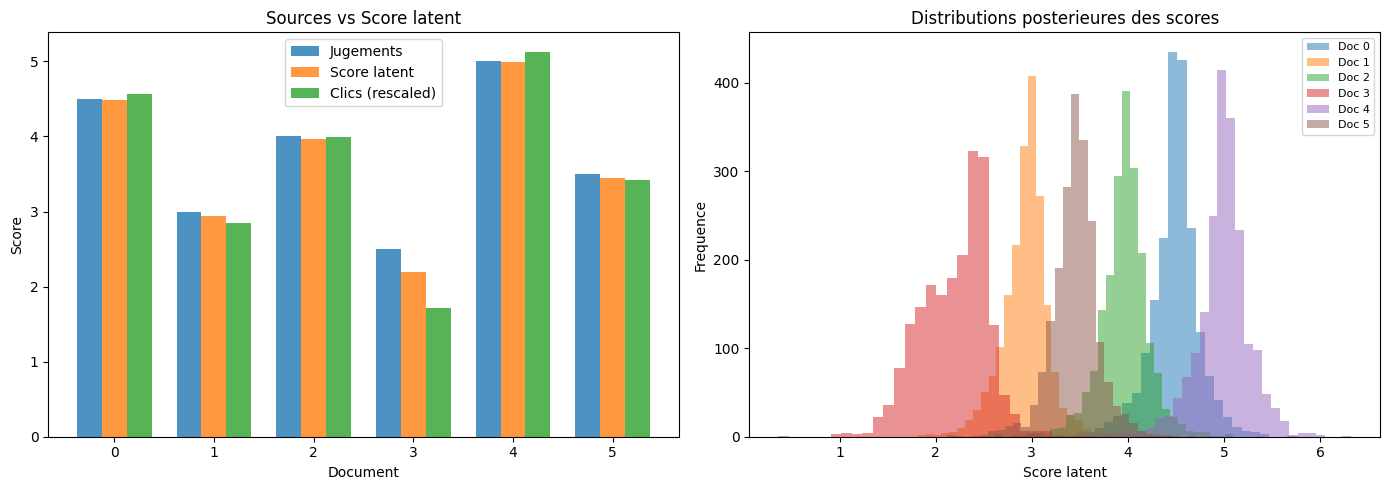

In [20]:
# Visualisation Click Model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gauche : comparaison sources vs score latent
docs = np.arange(n_docs)
width = 0.25
axes[0].bar(docs - width, judgements, width, label='Jugements', alpha=0.8)
axes[0].bar(docs, scores_post, width, label='Score latent', alpha=0.8)
axes[0].bar(docs + width, click_rates * (1/alpha_post), width, 
           label='Clics (rescaled)', alpha=0.8)
axes[0].set_xlabel('Document')
axes[0].set_ylabel('Score')
axes[0].set_title('Sources vs Score latent')
axes[0].legend()
axes[0].set_xticks(docs)

# Droite : posteriors des scores
for d in range(n_docs):
    samples = trace_click.posterior['scores'].sel(scores_dim_0=d).values.flatten()
    axes[1].hist(samples, bins=30, alpha=0.5, label=f'Doc {d}')
axes[1].set_xlabel('Score latent')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distributions posterieures des scores')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Exemple guide : Recommandation de Films

Application du modele de factorisation a un scenario de recommandation de films.

In [21]:
# Exemple guide : Recommandation de films
films = ['Inception', 'Titanic', 'Matrix', 'NotebookFilm', 'Terminator']
film_users = ['Alice', 'Bob', 'Charlie']

# Notes observees
film_user_obs = np.array([0,0,0, 1,1, 2,2])
film_item_obs = np.array([0,2,4, 1,3, 0,2])
film_ratings = np.array([5.0, 4.0, 4.5, 4.0, 5.0, 3.0, 2.0])

n_fu = len(film_users)
n_fi = len(films)
n_ft = 2

with pm.Model() as film_model:
    U_f = pm.Normal('U_f', mu=0, sigma=2, shape=(n_fu, n_ft))
    V_f = pm.Normal('V_f', mu=0, sigma=2, shape=(n_fi, n_ft))
    sigma_f = pm.HalfNormal('sigma_f', sigma=0.5)
    
    pred_f = (U_f[film_user_obs] * V_f[film_item_obs]).sum(axis=1)
    obs_f = pm.Normal('obs_f', mu=pred_f, sigma=sigma_f, observed=film_ratings)

with film_model:
    trace_film = pm.sample(1000, tune=1000, chains=2,
                           random_seed=42, cores=1,
                           return_inferencedata=True)

# Predictions
U_f_post = trace_film.posterior['U_f'].mean(dim=['chain', 'draw']).values
V_f_post = trace_film.posterior['V_f'].mean(dim=['chain', 'draw']).values
R_film = U_f_post @ V_f_post.T

print("=== Recommandations de Films ===")
print(f"{'':>10}", end="")
for f in films:
    print(f"{f:>12}", end="")
print()
for u in range(n_fu):
    print(f"{film_users[u]:>10}", end="")
    for i in range(n_fi):
        print(f"{R_film[u,i]:>12.2f}", end="")
    print()

# Top recommandations
print("\nTop recommandations :")
for u in range(n_fu):
    seen = set(film_item_obs[film_user_obs == u])
    unseen_scores = [(i, R_film[u, i]) for i in range(n_fi) if i not in seen]
    unseen_scores.sort(key=lambda x: -x[1])
    if unseen_scores:
        best = unseen_scores[0]
        print(f"  {film_users[u]} : {films[best[0]]} (score: {best[1]:.2f})")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [U_f, V_f, sigma_f]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 14 seconds.


There were 108 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


=== Recommandations de Films ===
             Inception     Titanic      MatrixNotebookFilm  Terminator
     Alice        0.01       -0.00        0.00       -0.01        0.01
       Bob       -0.01        0.01       -0.01        0.02       -0.01
   Charlie        0.00       -0.00        0.00       -0.01        0.00

Top recommandations :
  Alice : Titanic (score: -0.00)
  Bob : Matrix (score: -0.01)
  Charlie : Terminator (score: 0.00)


## 7. Bilan : Systemes de recommandation bayesiens

| Modele | Usage | Points cles |
|--------|-------|-------------|
| **Factorisation** | Decomposition U x V des preferences | Traits latents, NUTS, uncertainite sur les predictions |
| **Cold-Start** | Nouveaux users/items | Features + regression, prediction basee sur caracteristiques |
| **Click Model** | Fusion multi-sources | Score latent unique, reconciliation jugements + clics |

## 8. Resume

| Concept | Description |
|---------|-------------|
| **Factorisation matricielle** | $R \approx U \cdot V^T$ avec priors bayesiens |
| **Traits latents** | Dimensions cachees capturant les preferences |
| **Cold-start** | Utiliser les features pour les nouveaux users/items |
| **Click model** | Fusionner plusieurs sources via un score latent |
| **Incertitude** | PyMC quantifie l'incertitude sur chaque prediction |

## Distributions utilisees

| Distribution | Usage | Parametres |
|-------------|-------|------------|
| `Normal` | Priors traits, vraisemblance notes | $\mu, \sigma$ |
| `HalfNormal` | Priors bruit | $\sigma$ |
| `Deterministic` | Produit scalaire uTv | Valeur determinee |

## 9. Exercice : Recommandation de Musique

Appliquez la factorisation matricielle a la recommandation de musique.

**Consigne** : Completez le code ci-dessous pour :
1. Definir les observations (3 utilisateurs, 4 artistes)
2. Construire le modele PyMC de factorisation
3. Executer l'inference
4. Afficher les recommandations pour chaque utilisateur

In [22]:
# Exercice : Recommandation de musique
# Artists : 0=DaftPunk, 1=Beatles, 2=Mozart, 3= Nirvana

# TODO etudiant : definissez les observations
artists = ['DaftPunk', 'Beatles', 'Mozart', 'Nirvana']
music_users = ['User1', 'User2', 'User3']

# Indices des observations (utilisateur, artiste, note)
m_user_obs = np.array([0, 0, 1, 1, 2, 2])
m_item_obs = np.array([0, 3, 1, 2, 0, 1])
m_ratings = np.array([5.0, 4.0, 5.0, 3.0, 4.0, 2.0])

n_mu = len(music_users)
n_mi = len(artists)
n_mt = 2

print("Exercice a completer : ajoutez le modele PyMC et l'inference ci-dessous.")
print(f"Users: {music_users}, Artists: {artists}")
print(f"Observations: {len(m_ratings)} notes")

# TODO etudiant : construisez et executez le modele de factorisation ici
# Indice : inspirez-vous du modele mf_model2 ci-dessus
# Etape 1 : definir le modele avec pm.Model()
# Etape 2 : definir les priors U, V et sigma
# Etape 3 : definir la vraisemblance
# Etape 4 : echantillonner avec pm.sample()
# Etape 5 : afficher les predictions et recommandations

Exercice a completer : ajoutez le modele PyMC et l'inference ci-dessous.
Users: ['User1', 'User2', 'User3'], Artists: ['DaftPunk', 'Beatles', 'Mozart', 'Nirvana']
Observations: 6 notes


---

**Navigation** : [PyMC-11-Sequences](PyMC-11-Sequences.ipynb) | [Index](README.md)